<a href="https://colab.research.google.com/github/omargamal233/ensemble-learning-/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from collections import Counter

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, learning_curve

sns.set(style='white', context='notebook', palette='deep')


In [3]:
# Load data
##### Load train and Test set

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")
IDtest = test["PassengerId"]

In [4]:
# Outlier detection

def detect_outliers(df,n,features):
    """
    Takes a dataframe df of features and returns a list of the indices
    corresponding to the observations containing more than n outliers according
    to the Tukey method.
    """
    outlier_indices = []

    # iterate over features(columns)
    for col in features:
        # 1st quartile (25%)
        Q1 = np.percentile(df[col], 25)
        # 3rd quartile (75%)
        Q3 = np.percentile(df[col],75)
        # Interquartile range (IQR)
        IQR = Q3 - Q1

        # outlier step
        outlier_step = 1.5 * IQR

        # Determine a list of indices of outliers for feature col
        outlier_list_col = df[(df[col] < Q1 - outlier_step) | (df[col] > Q3 + outlier_step )].index

        # append the found outlier indices for col to the list of outlier indices
        outlier_indices.extend(outlier_list_col)

    # select observations containing more than 2 outliers
    outlier_indices = Counter(outlier_indices)
    multiple_outliers = list( k for k, v in outlier_indices.items() if v > n )

    return multiple_outliers

# detect outliers from Age, SibSp , Parch and Fare
Outliers_to_drop = detect_outliers(train,2,["Age","SibSp","Parch","Fare"])

In [5]:
train.loc[Outliers_to_drop] # Show the outliers rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.00,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.00,C23 C25 C27,S
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.00,C23 C25 C27,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [6]:
train = train.drop(Outliers_to_drop, axis = 0).reset_index(drop=True)

In [7]:
## Join train and test datasets in order to obtain the same number of features during categorical conversion
train_len = len(train)
dataset =  pd.concat(objs=[train, test], axis=0).reset_index(drop=True)

In [8]:
# Fill empty and NaNs values with NaN
dataset = dataset.fillna(np.nan)

# Check for Null values
dataset.isnull().sum()


,0
PassengerId,0
Survived,418
Pclass,0
Name,0
Sex,0
Age,256
SibSp,0
Parch,0
Ticket,0
Fare,1


In [9]:
# Infos
train.info()
train.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 881 entries, 0 to 880
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  881 non-null    int64  
 1   Survived     881 non-null    int64  
 2   Pclass       881 non-null    int64  
 3   Name         881 non-null    object 
 4   Sex          881 non-null    object 
 5   Age          711 non-null    float64
 6   SibSp        881 non-null    int64  
 7   Parch        881 non-null    int64  
 8   Ticket       881 non-null    object 
 9   Fare         881 non-null    float64
 10  Cabin        201 non-null    object 
 11  Embarked     879 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 82.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,170
SibSp,0
Parch,0
Ticket,0
Fare,0


In [10]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
train.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [12]:
### Summarize data
# Summarie and statistics
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,881.000000,881.000000,881.000000,711.000000,881.000000,881.000000,881.000000
mean,446.713961,0.385925,2.307605,29.731603,0.455165,0.363224,31.121566
std,256.617021,0.487090,0.835055,14.547835,0.871571,0.791839,47.996249
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,226.000000,0.000000,2.000000,20.250000,0.000000,0.000000,7.895800
50%,448.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.000000,1.000000,3.000000,38.000000,1.000000,0.000000,30.500000
max,891.000000,1.000000,3.000000,80.000000,5.000000,6.000000,512.329200


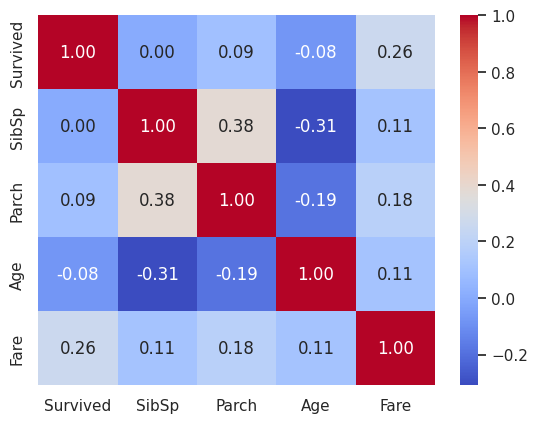

In [13]:
# Correlation matrix between numerical values (SibSp Parch Age and Fare values) and Survived
g = sns.heatmap(train[["Survived","SibSp","Parch","Age","Fare"]].corr(),annot=True, fmt = ".2f", cmap = "coolwarm")

/tmp/ipykernel_10879/1585326234.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


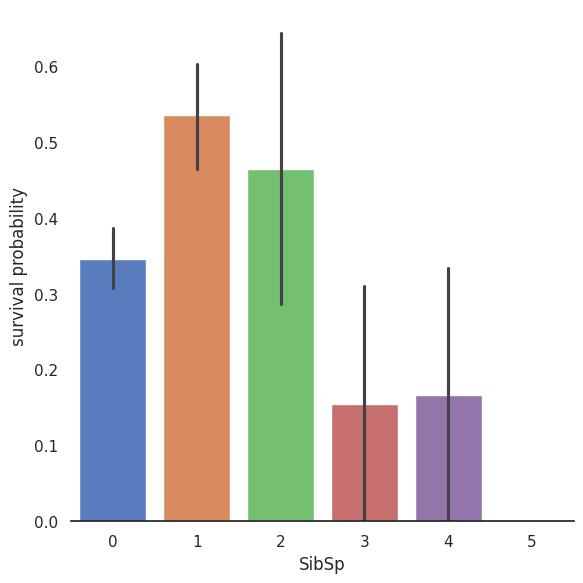

In [15]:
g = sns.catplot(
    x="SibSp",
    y="Survived",
    data=train,
    kind="bar",
    height=6,
    palette="muted"
)

g.despine(left=True)
g.set_ylabels("survival probability")

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)


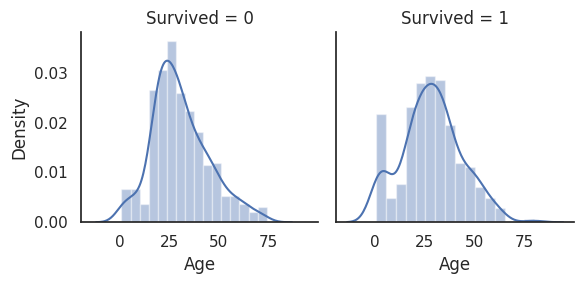

In [16]:
# Explore Age vs Survived
g = sns.FacetGrid(train, col='Survived')
g = g.map(sns.distplot, "Age")



/tmp/ipykernel_10879/1732533048.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  g = sns.kdeplot(train["Age"][(train["Survived"] == 0) & (train["Age"].notnull())], color="Red", shade = True)
/tmp/ipykernel_10879/1732533048.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  g = sns.kdeplot(train["Age"][(train["Survived"] == 1) & (train["Age"].notnull())], ax =g, color="Blue", shade= True)


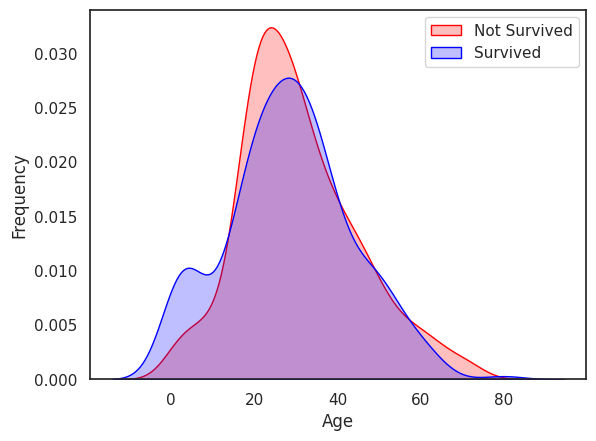

In [17]:
# Explore Age distibution
g = sns.kdeplot(train["Age"][(train["Survived"] == 0) & (train["Age"].notnull())], color="Red", shade = True)
g = sns.kdeplot(train["Age"][(train["Survived"] == 1) & (train["Age"].notnull())], ax =g, color="Blue", shade= True)
g.set_xlabel("Age")
g.set_ylabel("Frequency")
g = g.legend(["Not Survived","Survived"])

In [18]:
dataset["Fare"].isnull().sum()

np.int64(1)

In [19]:
#Fill Fare missing values with the median value
dataset["Fare"] = dataset["Fare"].fillna(dataset["Fare"].median())

/tmp/ipykernel_10879/2384613685.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  g = sns.distplot(dataset["Fare"], color="m", label="Skewness : %.2f"%(dataset["Fare"].skew()))


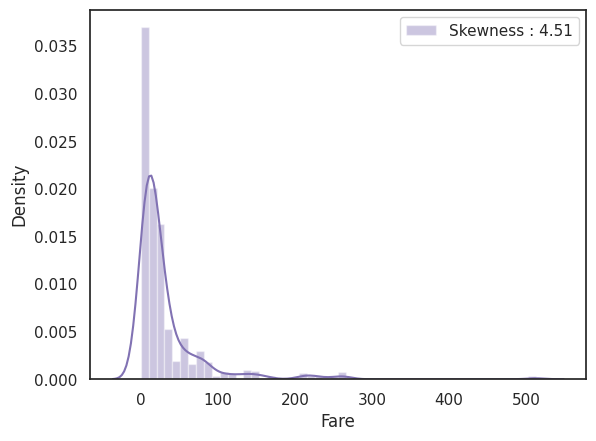

In [20]:
# Explore Fare distribution
g = sns.distplot(dataset["Fare"], color="m", label="Skewness : %.2f"%(dataset["Fare"].skew()))
g = g.legend(loc="best")

In [21]:
# Apply log to Fare to reduce skewness distribution
dataset["Fare"] = dataset["Fare"].map(lambda i: np.log(i) if i > 0 else 0)

/tmp/ipykernel_10879/846037914.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  g = sns.distplot(dataset["Fare"], color="b", label="Skewness : %.2f"%(dataset["Fare"].skew()))


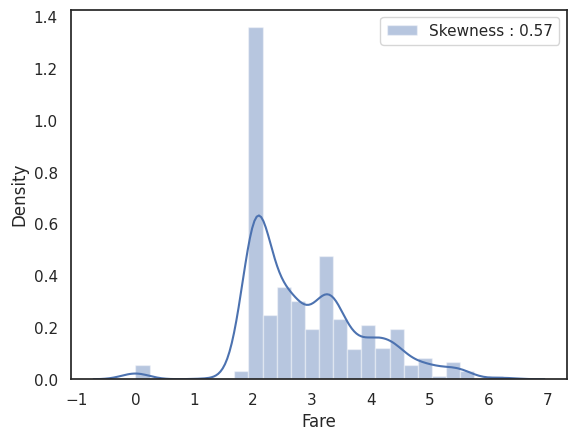

In [22]:
g = sns.distplot(dataset["Fare"], color="b", label="Skewness : %.2f"%(dataset["Fare"].skew()))
g = g.legend(loc="best")

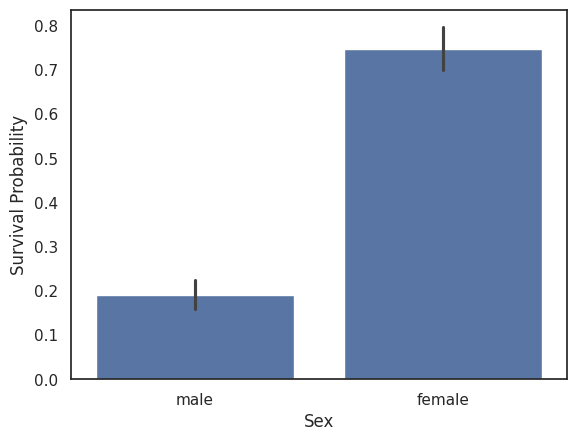

In [23]:
g = sns.barplot(x="Sex",y="Survived",data=train)
g = g.set_ylabel("Survival Probability")

In [24]:
train[["Sex","Survived"]].groupby('Sex').mean()

,Survived
Sex,
female,0.747573
male,0.190559


/tmp/ipykernel_10879/2550734137.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


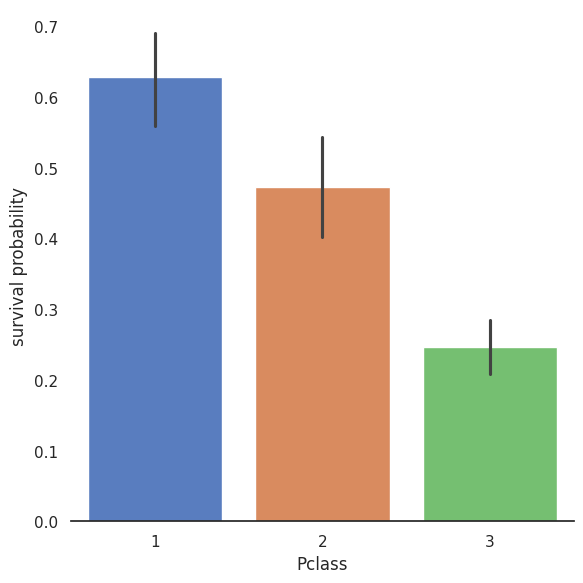

In [26]:
g = sns.catplot(
    x="Pclass",
    y="Survived",
    data=train,
    kind="bar",
    height=6,
    palette="muted"
)

g.despine(left=True)
g.set_ylabels("survival probability")

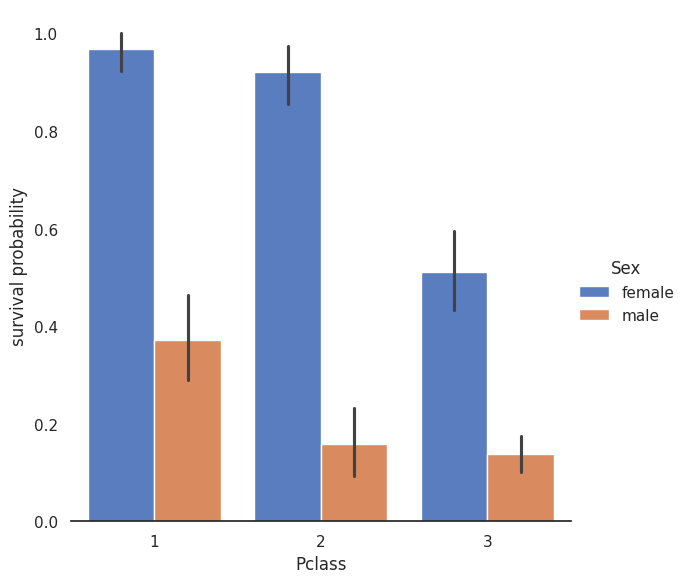

In [29]:
# Explore Pclass vs Survived by Sex
g = sns.catplot(
    x="Pclass",
    y="Survived",
    hue="Sex",
    data=train,
    height=6,
    kind="bar",
    palette="muted"
)

g.despine(left=True)
g.set_ylabels("survival probability")

In [30]:
dataset["Embarked"].isnull().sum()

np.int64(2)

In [31]:
#Fill Embarked nan values of dataset set with 'S' most frequent value
dataset["Embarked"] = dataset["Embarked"].fillna("S")

/tmp/ipykernel_10879/1812493231.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


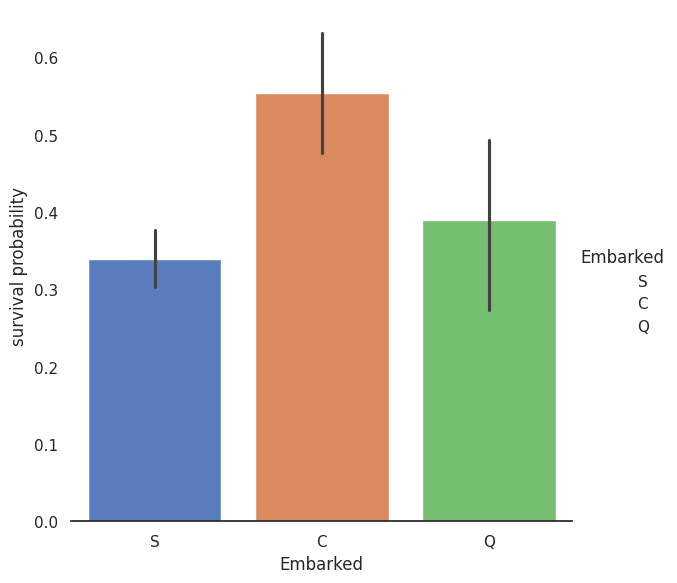

In [33]:
# Explore Embarked vs Survived
g = sns.catplot(
    x="Embarked",
    y="Survived",
    data=train,
    height=6,
    kind="bar",
    palette="muted"
)

g.despine(left=True)
g.set_ylabels("survival probability")

/tmp/ipykernel_10879/3241831279.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


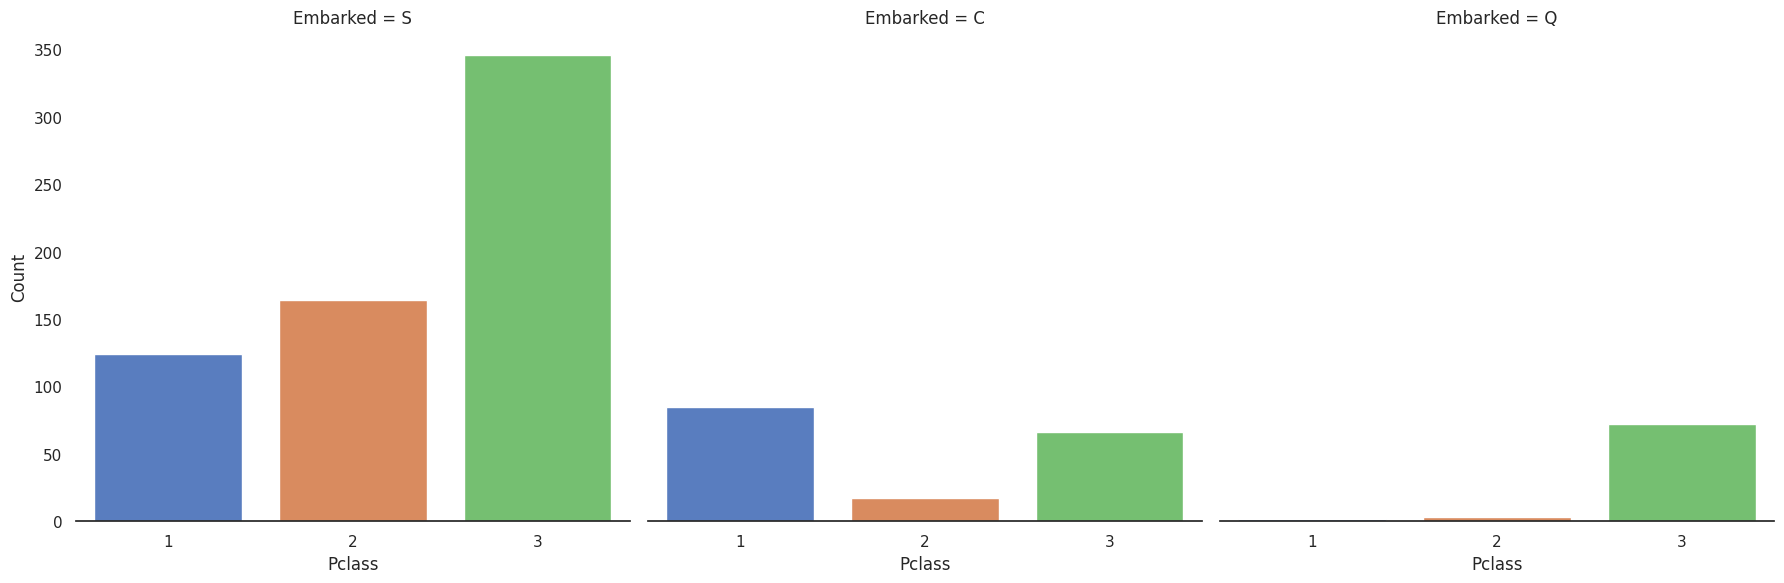

In [37]:
g = sns.catplot(
    x="Pclass",
    col="Embarked",
    data=train,
    height=6,
    kind="count",
    palette="muted"
)

g.despine(left=True)
g.set_ylabels("Count")

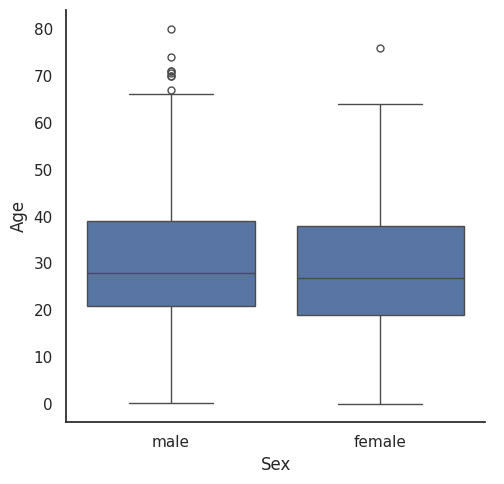

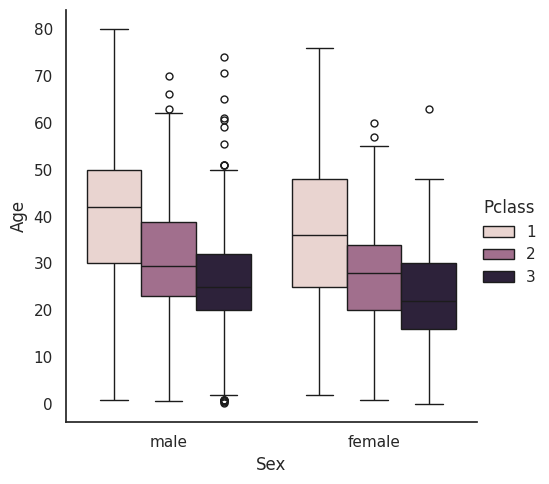

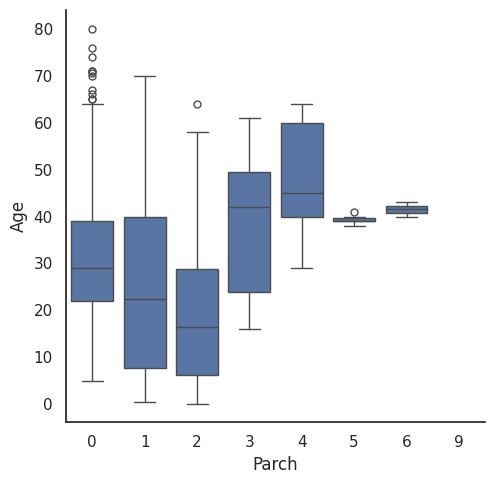

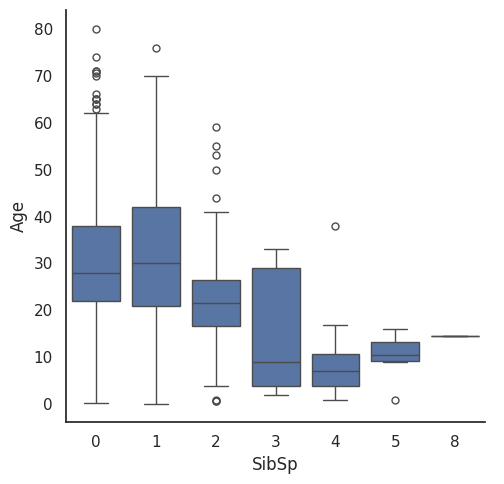

In [38]:
# Explore Age vs Sex, Parch , Pclass and SibSP
g = sns.catplot(y="Age",x="Sex",data=dataset,kind="box")
g = sns.catplot(y="Age",x="Sex",hue="Pclass", data=dataset,kind="box")
g = sns.catplot(y="Age",x="Parch", data=dataset,kind="box")
g = sns.catplot(y="Age",x="SibSp", data=dataset,kind="box")

In [39]:
# convert Sex into categorical value 0 for male and 1 for female
dataset["Sex"] = dataset["Sex"].map({"male": 0, "female":1})

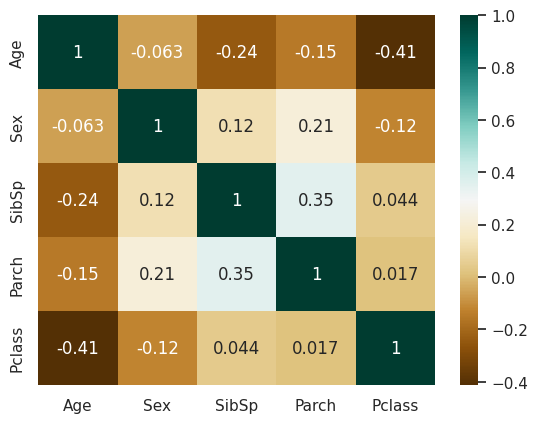

In [40]:
g = sns.heatmap(dataset[["Age","Sex","SibSp","Parch","Pclass"]].corr(),cmap="BrBG",annot=True)

In [41]:
# Filling missing value of Age

## Fill Age with the median age of similar rows according to Pclass, Parch and SibSp
# Index of NaN age rows
index_NaN_age = list(dataset["Age"][dataset["Age"].isnull()].index)

for i in index_NaN_age :
    age_med = dataset["Age"].median()
    age_pred = dataset["Age"][((dataset['SibSp'] == dataset.iloc[i]["SibSp"]) & (dataset['Parch'] == dataset.iloc[i]["Parch"]) & (dataset['Pclass'] == dataset.iloc[i]["Pclass"]))].median()
    if not np.isnan(age_pred) :
        dataset['Age'].iloc[i] = age_pred
    else :
        dataset['Age'].iloc[i] = age_med

/tmp/ipykernel_10879/2722654412.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  dataset['Age'].iloc[i] = age_pred
/tmp/ipykernel_10879/2722654412.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

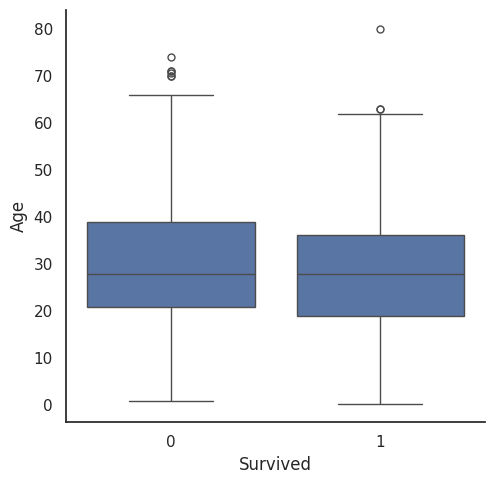

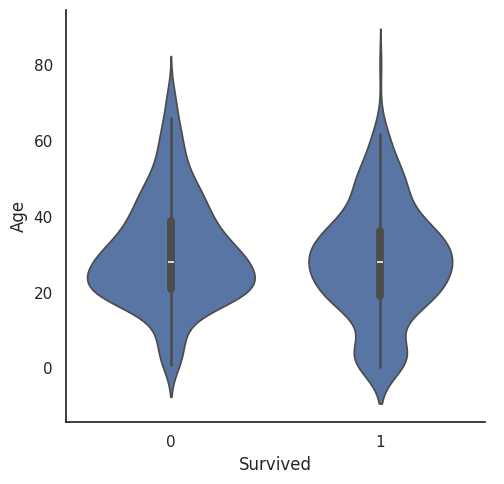

In [43]:
g = sns.catplot(x="Survived", y = "Age",data = train, kind="box")
g = sns.catplot(x="Survived", y = "Age",data = train, kind="violin")

In [44]:
dataset["Name"].head()

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"


In [45]:
# Get Title from Name
dataset_title = [i.split(",")[1].split(".")[0].strip() for i in dataset["Name"]]
dataset["Title"] = pd.Series(dataset_title)
dataset["Title"].head()

,Title
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr


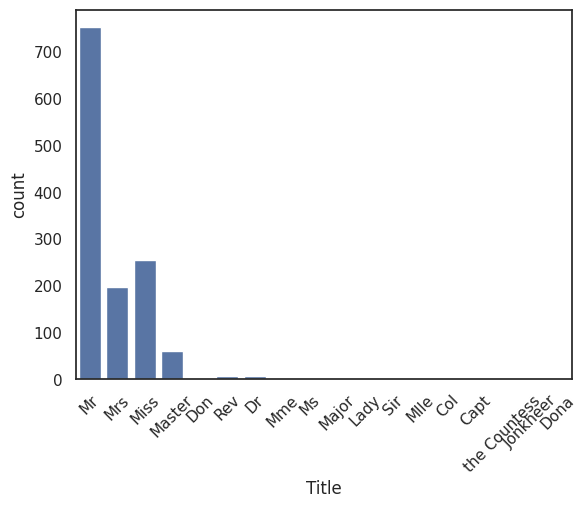

In [46]:
g = sns.countplot(x="Title",data=dataset)
g = plt.setp(g.get_xticklabels(), rotation=45)

In [47]:
# Convert to categorical values Title
dataset["Title"] = dataset["Title"].replace(['Lady', 'the Countess','Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
dataset["Title"] = dataset["Title"].map({"Master":0, "Miss":1, "Ms" : 1 , "Mme":1, "Mlle":1, "Mrs":1, "Mr":2, "Rare":3})
dataset["Title"] = dataset["Title"].astype(int)

/tmp/ipykernel_10879/3987800518.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g = g.set_xticklabels(["Master","Miss/Ms/Mme/Mlle/Mrs","Mr","Rare"])


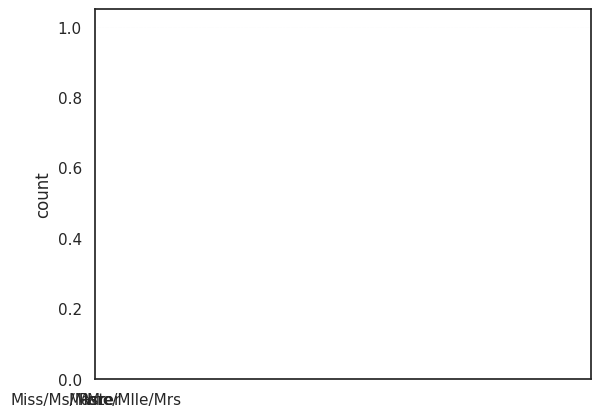

In [48]:
g = sns.countplot(dataset["Title"])
g = g.set_xticklabels(["Master","Miss/Ms/Mme/Mlle/Mrs","Mr","Rare"])

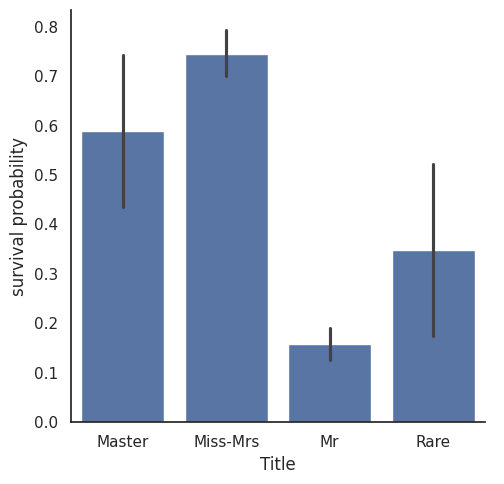

In [50]:
g = sns.catplot(x="Title",y="Survived",data=dataset,kind="bar")
g = g.set_xticklabels(["Master","Miss-Mrs","Mr","Rare"])
g = g.set_ylabels("survival probability")

In [51]:
# Drop Name variable
dataset.drop(labels = ["Name"], axis = 1, inplace = True)

In [52]:
# Create a family size descriptor from SibSp and Parch
dataset["Fsize"] = dataset["SibSp"] + dataset["Parch"] + 1

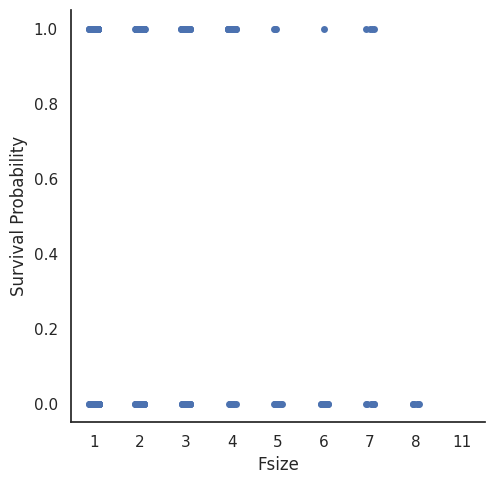

In [54]:
g = sns.catplot(x="Fsize",y="Survived",data = dataset)
g = g.set_ylabels("Survival Probability")

In [55]:
# Create new feature of family size
dataset['Single'] = dataset['Fsize'].map(lambda s: 1 if s == 1 else 0)
dataset['SmallF'] = dataset['Fsize'].map(lambda s: 1 if  s == 2  else 0)
dataset['MedF'] = dataset['Fsize'].map(lambda s: 1 if 3 <= s <= 4 else 0)
dataset['LargeF'] = dataset['Fsize'].map(lambda s: 1 if s >= 5 else 0)

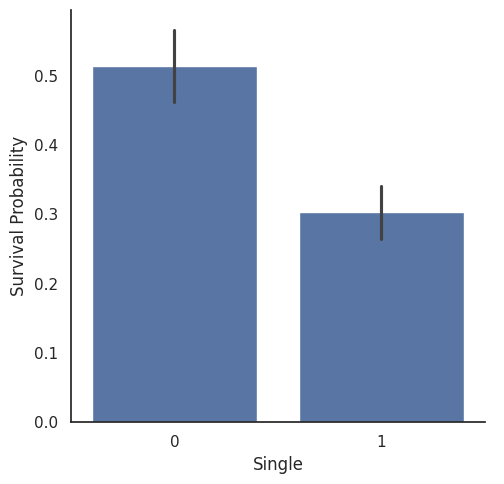

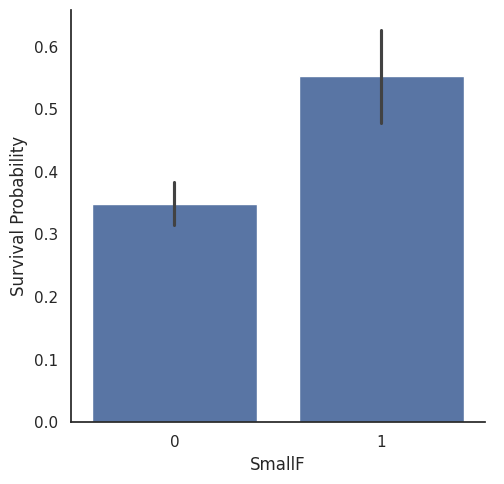

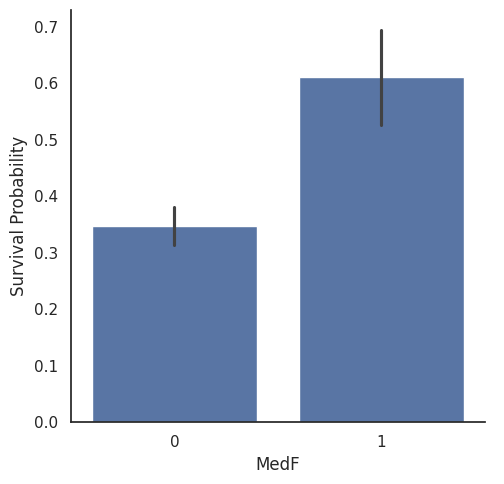

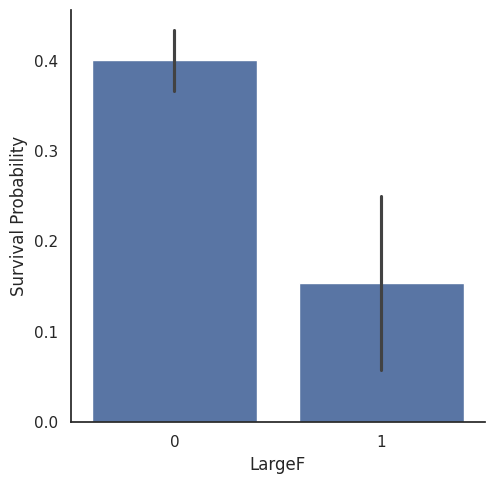

In [56]:
g = sns.catplot(x="Single",y="Survived",data=dataset,kind="bar")
g = g.set_ylabels("Survival Probability")
g = sns.catplot(x="SmallF",y="Survived",data=dataset,kind="bar")
g = g.set_ylabels("Survival Probability")
g = sns.catplot(x="MedF",y="Survived",data=dataset,kind="bar")
g = g.set_ylabels("Survival Probability")
g = sns.catplot(x="LargeF",y="Survived",data=dataset,kind="bar")
g = g.set_ylabels("Survival Probability")

In [57]:
# convert to indicator values Title and Embarked
dataset = pd.get_dummies(dataset, columns = ["Title"])
dataset = pd.get_dummies(dataset, columns = ["Embarked"], prefix="Em")

In [58]:
dataset.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,...,SmallF,MedF,LargeF,Title_0,Title_1,Title_2,Title_3,Em_C,Em_Q,Em_S
0,1,0.0,3,0,22.0,1,0,A/5 21171,1.981001,NaN,...,1,0,0,False,False,True,False,False,False,True
1,2,1.0,1,1,38.0,1,0,PC 17599,4.266662,C85,...,1,0,0,False,True,False,False,True,False,False
2,3,1.0,3,1,26.0,0,0,STON/O2. 3101282,2.070022,NaN,...,0,0,0,False,True,False,False,False,False,True
3,4,1.0,1,1,35.0,1,0,113803,3.972177,C123,...,1,0,0,False,True,False,False,False,False,True
4,5,0.0,3,0,35.0,0,0,373450,2.085672,NaN,...,0,0,0,False,False,True,False,False,False,True


In [59]:
dataset["Cabin"].head()

,Cabin
0,NaN
1,C85
2,NaN
3,C123
4,NaN


In [60]:
dataset["Cabin"].describe()

,Cabin
count,292
unique,186
top,G6
freq,5


In [61]:
dataset["Cabin"].isnull().sum()

np.int64(1007)

In [62]:
dataset["Cabin"][dataset["Cabin"].notnull()].head()

,Cabin
1,C85
3,C123
6,E46
10,G6
11,C103


In [63]:
# Replace the Cabin number by the type of cabin 'X' if not
dataset["Cabin"] = pd.Series([i[0] if not pd.isnull(i) else 'X' for i in dataset['Cabin'] ])

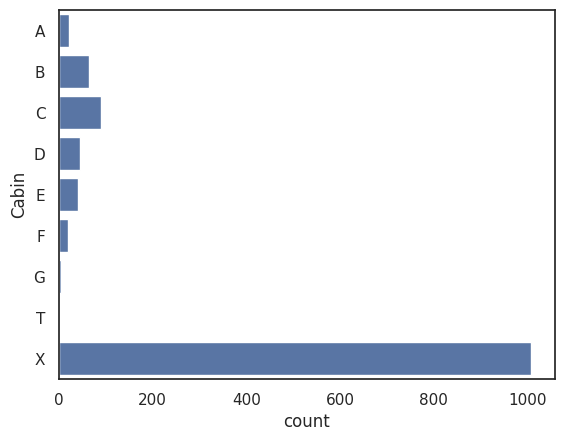

In [64]:
g = sns.countplot(dataset["Cabin"],order=['A','B','C','D','E','F','G','T','X'])

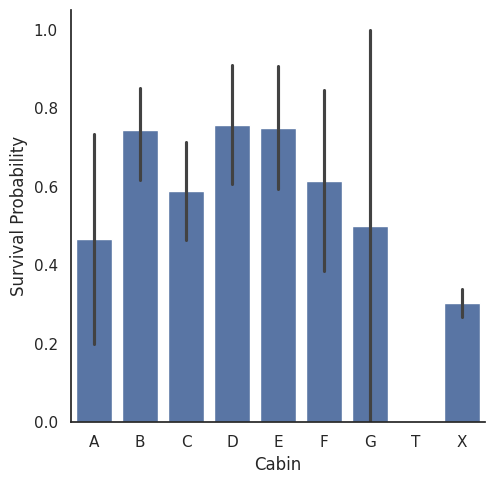

In [66]:
g = sns.catplot(y="Survived",x="Cabin",data=dataset,kind="bar",order=['A','B','C','D','E','F','G','T','X'])
g = g.set_ylabels("Survival Probability")

In [67]:
dataset = pd.get_dummies(dataset, columns = ["Cabin"],prefix="Cabin")

In [68]:
dataset["Ticket"].head()

,Ticket
0,A/5 21171
1,PC 17599
2,STON/O2. 3101282
3,113803
4,373450


In [69]:
## Treat Ticket by extracting the ticket prefix. When there is no prefix it returns X.

Ticket = []
for i in list(dataset.Ticket):
    if not i.isdigit() :
        Ticket.append(i.replace(".","").replace("/","").strip().split(' ')[0]) #Take prefix
    else:
        Ticket.append("X")

dataset["Ticket"] = Ticket
dataset["Ticket"].head()

,Ticket
0,A5
1,PC
2,STONO2
3,X
4,X


In [70]:
dataset = pd.get_dummies(dataset, columns = ["Ticket"], prefix="T")

In [71]:
# Create categorical values for Pclass
dataset["Pclass"] = dataset["Pclass"].astype("category")
dataset = pd.get_dummies(dataset, columns = ["Pclass"],prefix="Pc")

In [72]:
# Drop useless variables
dataset.drop(labels = ["PassengerId"], axis = 1, inplace = True)

In [73]:
dataset.head()

,Survived,Sex,Age,SibSp,Parch,Fare,Fsize,Single,SmallF,MedF,...,T_STONO,T_STONO2,T_STONOQ,T_SWPP,T_WC,T_WEP,T_X,Pc_1,Pc_2,Pc_3
0,0.0,0,22.0,1,0,1.981001,2,0,1,0,...,False,False,False,False,False,False,False,False,False,True
1,1.0,1,38.0,1,0,4.266662,2,0,1,0,...,False,False,False,False,False,False,False,True,False,False
2,1.0,1,26.0,0,0,2.070022,1,1,0,0,...,False,True,False,False,False,False,False,False,False,True
3,1.0,1,35.0,1,0,3.972177,2,0,1,0,...,False,False,False,False,False,False,True,True,False,False
4,0.0,0,35.0,0,0,2.085672,1,1,0,0,...,False,False,False,False,False,False,True,False,False,True


In [74]:
## Separate train dataset and test dataset

train = dataset[:train_len]
test = dataset[train_len:]
test.drop(labels=["Survived"],axis = 1,inplace=True)

/tmp/ipykernel_10879/1673638405.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.drop(labels=["Survived"],axis = 1,inplace=True)


In [75]:
## Separate train features and label

train["Survived"] = train["Survived"].astype(int)

Y_train = train["Survived"]

X_train = train.drop(labels = ["Survived"],axis = 1)

/tmp/ipykernel_10879/3125760867.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train["Survived"] = train["Survived"].astype(int)


In [76]:
# Cross validate model with Kfold stratified cross val
kfold = StratifiedKFold(n_splits=10)

SVC                          acc = 0.7310  ±0.0245
Decision Tree                acc = 0.7888  ±0.0351
AdaBoost                     acc = 0.8036  ±0.0401
Random Forest                acc = 0.7991  ±0.0207
Extra Trees                  acc = 0.8058  ±0.0305
Gradient Boosting            acc = 0.8263  ±0.0286
MLP                          acc = 0.8047  ±0.0176
KNeighbors                   acc = 0.7729  ±0.0495
Logistic Regression          acc = 0.8229  ±0.0282
LDA                          acc = 0.8229  ±0.0192

           Algorithm  CrossValMeans  CrossValErrors
  Gradient Boosting       0.826264        0.028591
                LDA       0.822919        0.019227
Logistic Regression       0.822880        0.028155
        Extra Trees       0.805848        0.030517
                MLP       0.804750        0.017627
           AdaBoost       0.803613        0.040112
      Random Forest       0.799055        0.020654
      Decision Tree       0.788828        0.035143
         KNeighbors       0.7

/tmp/ipykernel_10879/1470496795.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


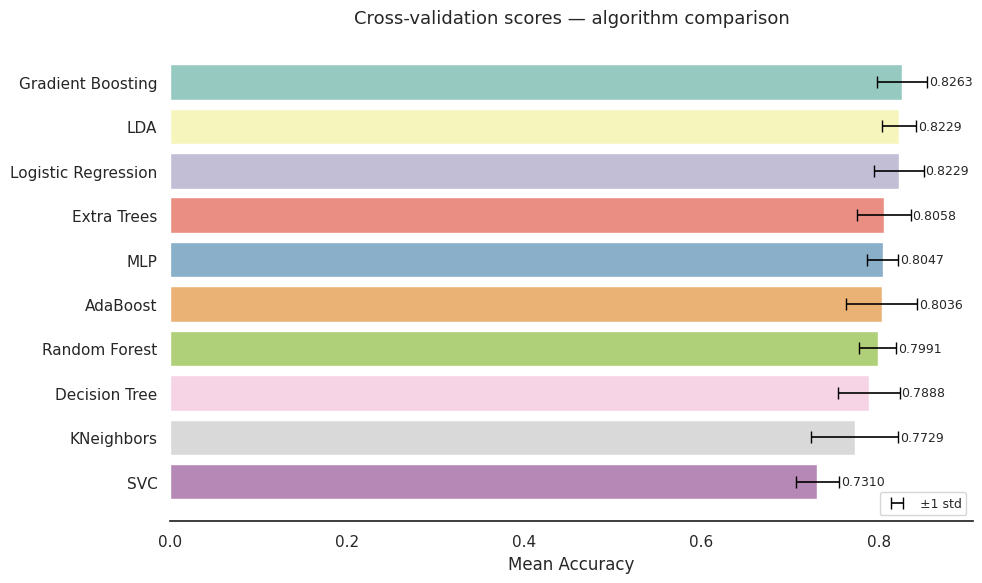

In [80]:


# ── Config ────────────────────────────────────────────────────────────────────
RANDOM_STATE = 2
N_FOLDS      = 10          # StratifiedKFold is more reliable than plain KFold

kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# ── Classifier registry (dict keeps names bound to models — no parallel lists)
classifiers = {
    "SVC":                      SVC(random_state=RANDOM_STATE, probability=True),
    "Decision Tree":            DecisionTreeClassifier(random_state=RANDOM_STATE),
    "AdaBoost":                 AdaBoostClassifier(
                                    estimator=DecisionTreeClassifier(max_depth=1),
                                    n_estimators=100,
                                    learning_rate=0.1,
                                    algorithm="SAMME",
                                    random_state=RANDOM_STATE),
    "Random Forest":            RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees":              ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":        GradientBoostingClassifier(random_state=RANDOM_STATE),
    "MLP":                      MLPClassifier(random_state=RANDOM_STATE, max_iter=500),
    "KNeighbors":               KNeighborsClassifier(),
    "Logistic Regression":      LogisticRegression(random_state=RANDOM_STATE,
                                                   max_iter=1000),
    "LDA":                      LinearDiscriminantAnalysis(),
}

# ── Cross-validation loop ─────────────────────────────────────────────────────
records = []

for name, clf in classifiers.items():
    scores = cross_val_score(
        clf, X_train, y=Y_train,
        scoring="accuracy",
        cv=kfold,
        n_jobs=-1          # use all cores; remove if your env doesn't support it
    )
    records.append({
        "Algorithm":      name,
        "CrossValMeans":  scores.mean(),
        "CrossValErrors": scores.std(),
    })
    print(f"{name:<28} acc = {scores.mean():.4f}  ±{scores.std():.4f}")

# ── Results DataFrame (sorted best → worst) ───────────────────────────────────
cv_res = (pd.DataFrame(records)
            .sort_values("CrossValMeans", ascending=False)
            .reset_index(drop=True))

print("\n", cv_res.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=cv_res,
    x="CrossValMeans",
    y="Algorithm",
    palette="Set3",
    orient="h",
    ax=ax,
)

# error bars added manually (xerr is not a valid seaborn barplot param)
ax.errorbar(
    x=cv_res["CrossValMeans"],
    y=range(len(cv_res)),
    xerr=cv_res["CrossValErrors"],
    fmt="none",
    color="black",
    capsize=4,
    linewidth=1.2,
    label="±1 std",
)

# value labels at the end of each bar
for i, row in cv_res.iterrows():
    ax.text(
        row["CrossValMeans"] + row["CrossValErrors"] + 0.002,
        i,
        f'{row["CrossValMeans"]:.4f}',
        va="center",
        fontsize=9,
    )

ax.set_xlabel("Mean Accuracy", fontsize=12)
ax.set_ylabel("")
ax.set_title("Cross-validation scores — algorithm comparison", fontsize=13, pad=14)
ax.set_xlim(0, cv_res["CrossValMeans"].max() + 0.08)
ax.legend(fontsize=9)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.savefig("cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [82]:

# ── Base estimator ────────────────────────────────────────────────────────────
DTC = DecisionTreeClassifier()

# ── AdaBoost wrapping the base estimator ─────────────────────────────────────
# 'estimator' replaces the deprecated 'base_estimator' (removed in sklearn 1.4)
adaDTC = AdaBoostClassifier(estimator=DTC, random_state=7, algorithm="SAMME")

# ── Hyperparameter grid ───────────────────────────────────────────────────────
# prefix 'estimator__' (not 'base_estimator__') to tunnel into the base DTC
ada_param_grid = {
    "estimator__criterion":  ["gini", "entropy"],
    "estimator__splitter":   ["best", "random"],
    "estimator__max_depth":  [1, 2, 3, 4],        # controls tree complexity
    "n_estimators":          [50, 100, 200],       # 1 & 2 are too weak in practice
    "learning_rate":         [0.0001, 0.001, 0.01, 0.1, 0.3, 1.0],
    # "SAMME.R" removed in sklearn 1.4 — use "SAMME" only
    "algorithm":             ["SAMME"],
}

# ── GridSearchCV ──────────────────────────────────────────────────────────────
gsadaDTC = GridSearchCV(
    estimator  = adaDTC,
    param_grid = ada_param_grid,
    cv         = kfold,
    scoring    = "accuracy",
    n_jobs     = -1,          # use all available cores
    verbose    = 1,
    refit      = True,        # refit best model on full training data (default)
    return_train_score = True # lets you check for overfitting later
)

gsadaDTC.fit(X_train, Y_train)

# ── Results ───────────────────────────────────────────────────────────────────
ada_best = gsadaDTC.best_estimator_

print("Best parameters :", gsadaDTC.best_params_)
print(f"Best CV accuracy : {gsadaDTC.best_score_:.4f}")

# Optional — full results as a sorted DataFrame
cv_results_df = (pd.DataFrame(gsadaDTC.cv_results_)
                   .sort_values("mean_test_score", ascending=False)
                   [["params", "mean_test_score", "std_test_score", "rank_test_score"]]
                   .reset_index(drop=True))

print("\nTop 5 parameter combinations:")
print(cv_results_df.head())

Fitting 10 folds for each of 288 candidates, totalling 2880 fits


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Best parameters : {'algorithm': 'SAMME', 'estimator__criterion': 'entropy', 'estimator__max_depth': 2, 'estimator__splitter': 'random', 'learning_rate': 1.0, 'n_estimators': 100}
Best CV accuracy : 0.8377

Top 5 parameter combinations:
                                              params  mean_test_score  \
0  {'algorithm': 'SAMME', 'estimator__criterion':...         0.837692   
1  {'algorithm': 'SAMME', 'estimator__criterion':...         0.835406   
2  {'algorithm': 'SAMME', 'estimator__criterion':...         0.834282   
3  {'algorithm': 'SAMME', 'estimator__criterion':...         0.833146   
4  {'algorithm': 'SAMME', 'estimator__criterion':...         0.833133   

   std_test_score  rank_test_score  
0        0.016813                1  
1        0.017852                2  
2        0.027902                3  
3        0.020961                4  
4        0.017730                5  


In [83]:
gsadaDTC.best_score_

np.float64(0.8376915219611849)

In [84]:
#ExtraTrees
ExtC = ExtraTreesClassifier()


## Search grid for optimal parameters
ex_param_grid = {"max_depth": [None],
              "max_features": [1, 3, 10],
              "min_samples_split": [2, 3, 10],
              "min_samples_leaf": [1, 3, 10],
              "bootstrap": [False],
              "n_estimators" :[100,300],
              "criterion": ["gini"]}


gsExtC = GridSearchCV(ExtC,param_grid = ex_param_grid, cv=kfold, scoring="accuracy", n_jobs= 4, verbose = 1)

gsExtC.fit(X_train,Y_train)

ExtC_best = gsExtC.best_estimator_

# Best score
gsExtC.best_score_


Fitting 10 folds for each of 54 candidates, totalling 540 fits


np.float64(0.8319841675178754)

In [85]:
# RFC Parameters tunning
RFC = RandomForestClassifier()


## Search grid for optimal parameters
rf_param_grid = {"max_depth": [None],
              "max_features": [1, 3, 10],
              "min_samples_split": [2, 3, 10],
              "min_samples_leaf": [1, 3, 10],
              "bootstrap": [False],
              "n_estimators" :[100,300],
              "criterion": ["gini"]}


gsRFC = GridSearchCV(RFC,param_grid = rf_param_grid, cv=kfold, scoring="accuracy", n_jobs= 4, verbose = 1)

gsRFC.fit(X_train,Y_train)

RFC_best = gsRFC.best_estimator_

# Best score
gsRFC.best_score_

Fitting 10 folds for each of 54 candidates, totalling 540 fits


np.float64(0.8342568947906027)

In [88]:


# ── Base estimator ────────────────────────────────────────────────────────────
GBC = GradientBoostingClassifier(random_state=42)

# ── Hyperparameter grid ───────────────────────────────────────────────────────
# 'loss="deviance"' was removed in sklearn 1.1 — replaced by 'log_loss'
gb_param_grid = {
    "loss":             ["log_loss", "exponential"],  # deviance → log_loss
    "n_estimators":     [100, 200, 300],
    "learning_rate":    [0.01, 0.05, 0.1],
    "max_depth":        [3, 4, 6],          # 8 is very deep → overfitting risk
    "min_samples_leaf": [50, 100, 150],     # added 50 for more flexibility
    "max_features":     ["sqrt", 0.3],      # float + named option
    "subsample":        [0.8, 1.0],         # adds stochastic GBM behaviour
}

# ── GridSearchCV ──────────────────────────────────────────────────────────────
gsGBC = GridSearchCV(
    estimator          = GBC,
    param_grid         = gb_param_grid,
    cv                 = kfold,
    scoring            = "accuracy",
    n_jobs             = -1,
    verbose            = 1,
    refit              = True,
    return_train_score = True,
)

gsGBC.fit(X_train, Y_train)

# ── Results ───────────────────────────────────────────────────────────────────
GBC_best = gsGBC.best_estimator_

print("Best parameters :", gsGBC.best_params_)
print(f"Best CV accuracy : {gsGBC.best_score_:.4f}")

# Train vs validation gap — quick overfitting check
cv_results_df = (pd.DataFrame(gsGBC.cv_results_)
                   .sort_values("mean_test_score", ascending=False)
                   [["params",
                     "mean_train_score", "std_train_score",
                     "mean_test_score",  "std_test_score",
                     "rank_test_score"]]
                   .reset_index(drop=True))

print("\nTop 5 parameter combinations:")
print(cv_results_df.head())

# Gap warning
best_row = cv_results_df.iloc[0]
gap = best_row["mean_train_score"] - best_row["mean_test_score"]
if gap > 0.05:
    print(f"\n⚠ Train/val gap = {gap:.4f} — consider reducing max_depth or increasing min_samples_leaf")
else:
    print(f"\n✓ Train/val gap = {gap:.4f} — model looks well generalised")

Fitting 10 folds for each of 648 candidates, totalling 6480 fits
Best parameters : {'learning_rate': 0.1, 'loss': 'log_loss', 'max_depth': 6, 'max_features': 0.3, 'min_samples_leaf': 50, 'n_estimators': 300, 'subsample': 0.8}
Best CV accuracy : 0.8365

Top 5 parameter combinations:
                                              params  mean_train_score  \
0  {'learning_rate': 0.1, 'loss': 'log_loss', 'ma...          0.894942   
1  {'learning_rate': 0.1, 'loss': 'exponential', ...          0.901122   
2  {'learning_rate': 0.1, 'loss': 'exponential', ...          0.867825   
3  {'learning_rate': 0.1, 'loss': 'log_loss', 'ma...          0.897337   
4  {'learning_rate': 0.1, 'loss': 'exponential', ...          0.888510   

   std_train_score  mean_test_score  std_test_score  rank_test_score  
0         0.005813         0.836491        0.040241                1  
1         0.004704         0.835342        0.043661                2  
2         0.006494         0.830822        0.032911        

In [89]:
### SVC classifier
SVMC = SVC(probability=True)
svc_param_grid = {'kernel': ['rbf'],
                  'gamma': [ 0.001, 0.01, 0.1, 1],
                  'C': [1, 10, 50, 100,200,300, 1000]}

gsSVMC = GridSearchCV(SVMC,param_grid = svc_param_grid, cv=kfold, scoring="accuracy", n_jobs= 4, verbose = 1)

gsSVMC.fit(X_train,Y_train)

SVMC_best = gsSVMC.best_estimator_

# Best score
gsSVMC.best_score_

Fitting 10 folds for each of 28 candidates, totalling 280 fits


np.float64(0.831996935648621)

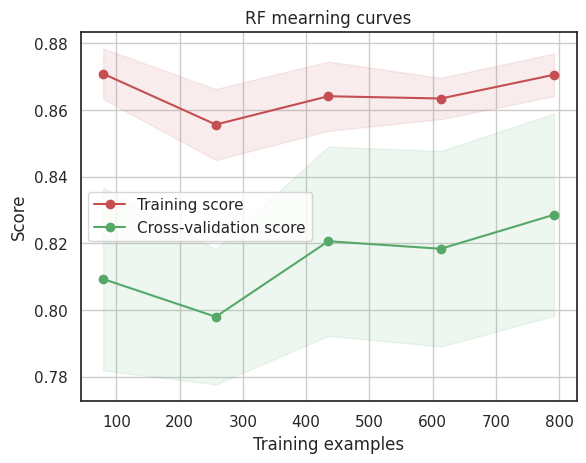

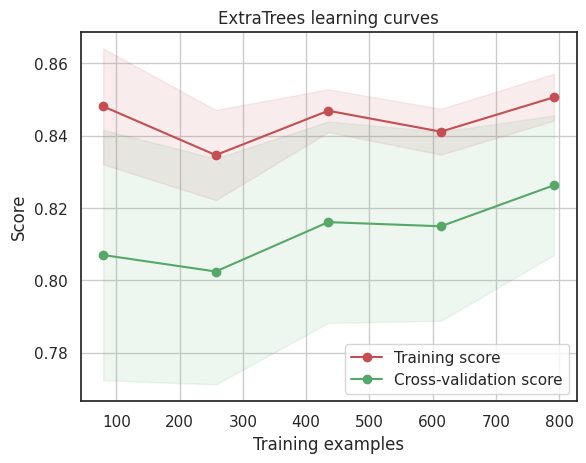

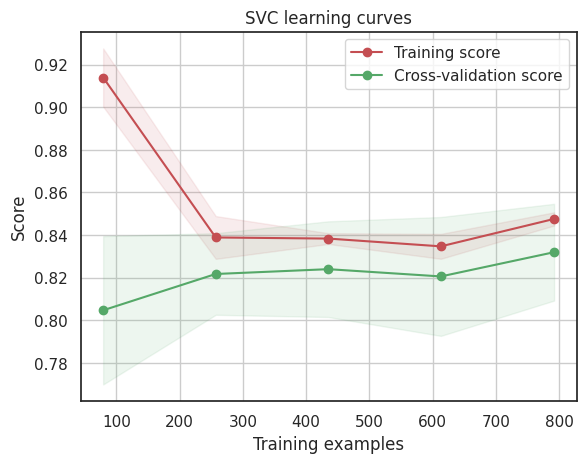

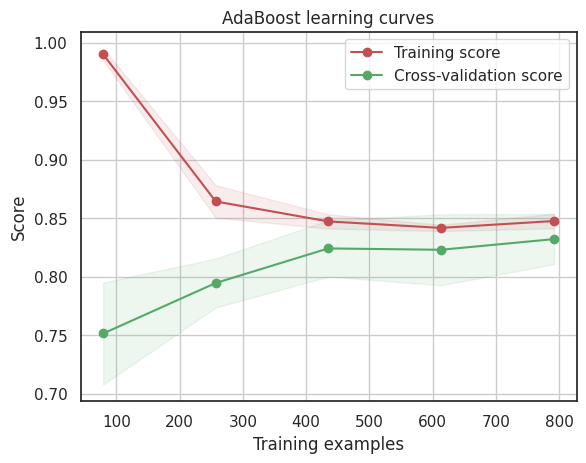

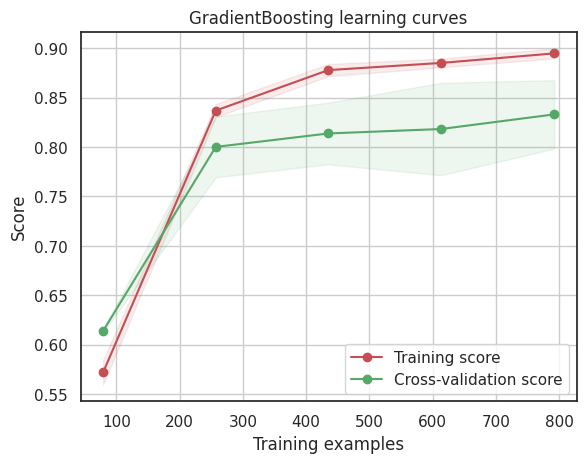

In [90]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    """Generate a simple plot of the test and training learning curve"""
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Cross-validation score")

    plt.legend(loc="best")
    return plt

g = plot_learning_curve(gsRFC.best_estimator_,"RF mearning curves",X_train,Y_train,cv=kfold)
g = plot_learning_curve(gsExtC.best_estimator_,"ExtraTrees learning curves",X_train,Y_train,cv=kfold)
g = plot_learning_curve(gsSVMC.best_estimator_,"SVC learning curves",X_train,Y_train,cv=kfold)
g = plot_learning_curve(gsadaDTC.best_estimator_,"AdaBoost learning curves",X_train,Y_train,cv=kfold)
g = plot_learning_curve(gsGBC.best_estimator_,"GradientBoosting learning curves",X_train,Y_train,cv=kfold)



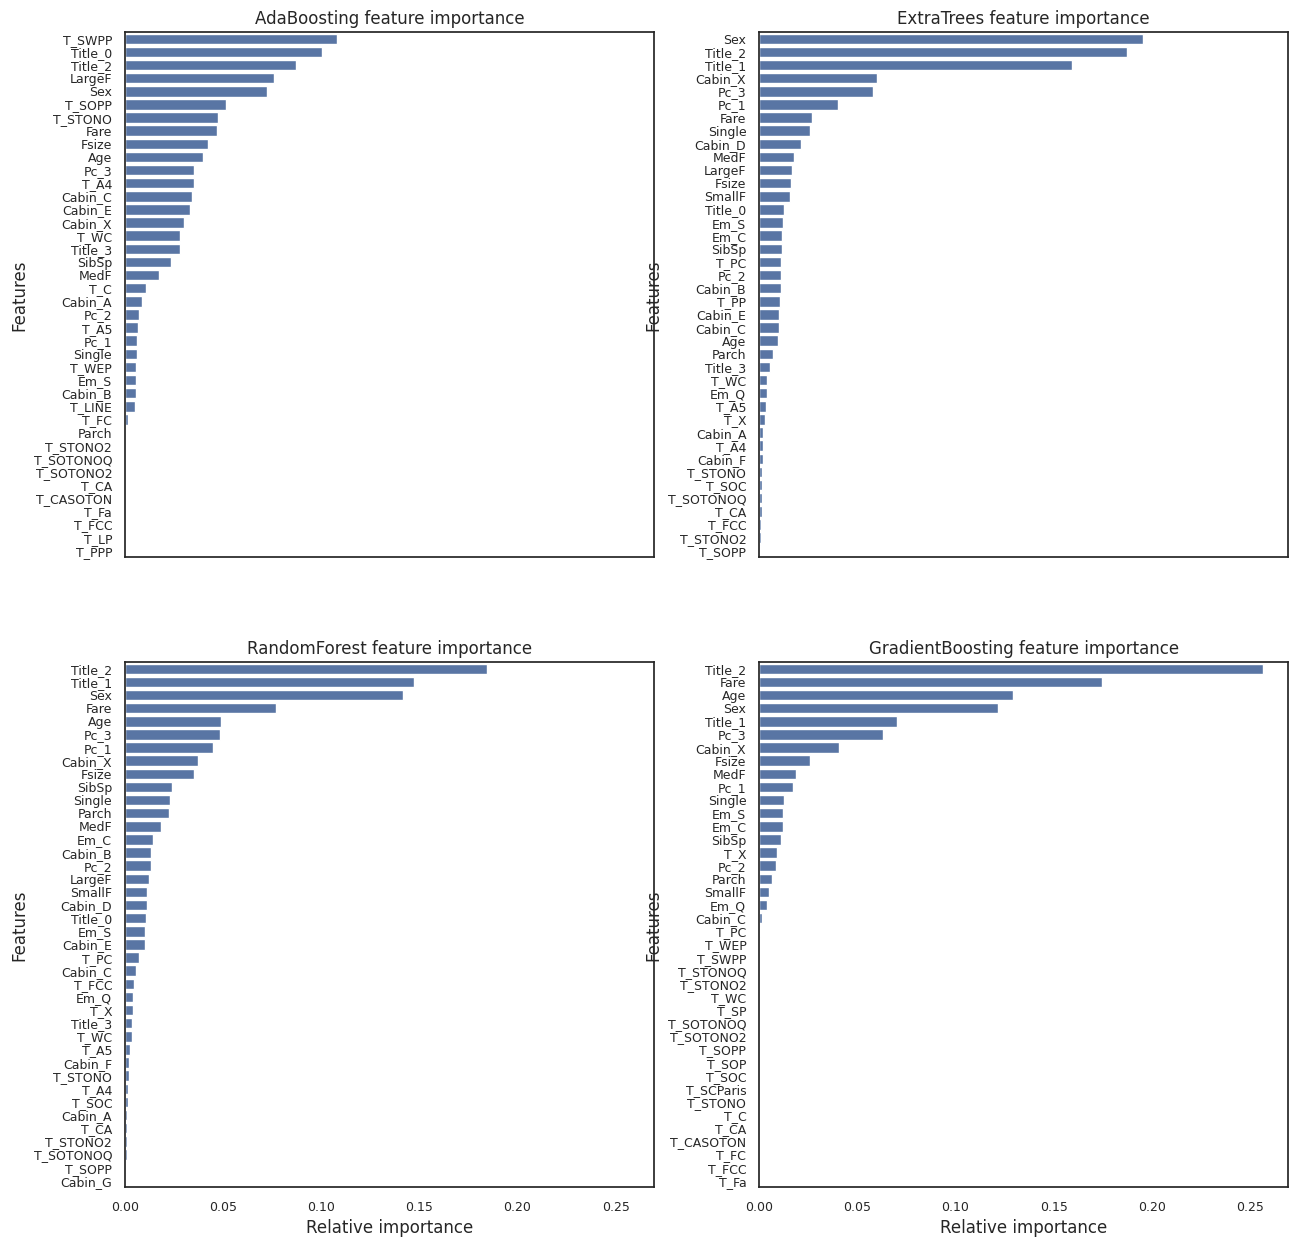

In [91]:
nrows = ncols = 2
fig, axes = plt.subplots(nrows = nrows, ncols = ncols, sharex="all", figsize=(15,15))

names_classifiers = [("AdaBoosting", ada_best),("ExtraTrees",ExtC_best),("RandomForest",RFC_best),("GradientBoosting",GBC_best)]

nclassifier = 0
for row in range(nrows):
    for col in range(ncols):
        name = names_classifiers[nclassifier][0]
        classifier = names_classifiers[nclassifier][1]
        indices = np.argsort(classifier.feature_importances_)[::-1][:40]
        g = sns.barplot(y=X_train.columns[indices][:40],x = classifier.feature_importances_[indices][:40] , orient='h',ax=axes[row][col])
        g.set_xlabel("Relative importance",fontsize=12)
        g.set_ylabel("Features",fontsize=12)
        g.tick_params(labelsize=9)
        g.set_title(name + " feature importance")
        nclassifier += 1

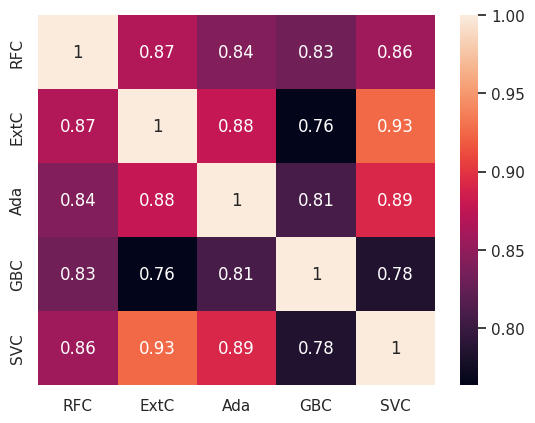

In [92]:
test_Survived_RFC = pd.Series(RFC_best.predict(test), name="RFC")
test_Survived_ExtC = pd.Series(ExtC_best.predict(test), name="ExtC")
test_Survived_SVMC = pd.Series(SVMC_best.predict(test), name="SVC")
test_Survived_AdaC = pd.Series(ada_best.predict(test), name="Ada")
test_Survived_GBC = pd.Series(GBC_best.predict(test), name="GBC")


# Concatenate all classifier results
ensemble_results = pd.concat([test_Survived_RFC,test_Survived_ExtC,test_Survived_AdaC,test_Survived_GBC, test_Survived_SVMC],axis=1)


g= sns.heatmap(ensemble_results.corr(),annot=True)

In [93]:
votingC = VotingClassifier(estimators=[('rfc', RFC_best), ('extc', ExtC_best),
('svc', SVMC_best), ('adac',ada_best),('gbc',GBC_best)], voting='soft', n_jobs=4)

votingC = votingC.fit(X_train, Y_train)

In [94]:
test_Survived = pd.Series(votingC.predict(test), name="Survived")

results = pd.concat([IDtest,test_Survived],axis=1)

results.to_csv("ensemble_python_voting.csv",index=False)